# Colorization model with homemade U-Net

## Imports

In [8]:
#Algebra
import numpy as np

#Graphics
import matplotlib.pyplot as plt
%matplotlib inline
from PIL import Image

#Deep learning
import tensorflow as tf
import tensorflow_io as tfio

from keras.models import Model
from keras import optimizers, callbacks
from keras.layers import Input, Flatten, Reshape, BatchNormalization, Concatenate
from keras.layers import Conv2D, MaxPooling2D, Conv2DTranspose, Activation
from keras.utils import image_dataset_from_directory

#Saving models
import joblib

2026-05-20 15:24:55.579993: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779290695.738741      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779290695.785378      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779290696.156721      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779290696.156772      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779290696.156774      57 computation_placer.cc:177] computation placer alr

## Training dataset

In [9]:
train_data_dir = '/kaggle/input/datasets/aayush9753/image-colorization-dataset/data/train_color'

# train_data_dir = '/kaggle/input/datasets/tamlacroix/tiny-train'

## Parameters

In [10]:
BATCH_SIZE = 64 32

IMAGE_HEIGHT = 256
IMAGE_WIDTH = 256
IMAGE_SIZE = (IMAGE_HEIGHT, IMAGE_WIDTH)
NUM_CHANNELS = 3

SEED = 42

LEARNING_RATE = 0.001
PATIENCE = 10
EPOCHS = 200

In [11]:
train_ds, val_ds = image_dataset_from_directory(
    train_data_dir,
    labels=None,
    seed=SEED,
    validation_split=0.2,
    subset='both',
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE)

Found 5000 files.
Using 4000 files for training.
Using 1000 files for validation.


I0000 00:00:1779290733.422535      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1779290733.428476      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


## Converting RGB to Lab

In [12]:
def rgb_to_lab(image):
    image = tf.cast(image, tf.float32) / 255.0
    lab = tfio.experimental.color.rgb_to_lab(image)
    L = lab[:, :, :, :1] / 100.
    ab = lab[:, :, :, 1:] / 128.
    return (L, ab)

In [13]:
train_ds_lab = train_ds.map(rgb_to_lab, num_parallel_calls=tf.data.AUTOTUNE)
train_ds_lab = train_ds_lab.prefetch(tf.data.AUTOTUNE)
val_ds_lab = val_ds.map(rgb_to_lab, num_parallel_calls=tf.data.AUTOTUNE)
val_ds_lab = val_ds_lab.prefetch(tf.data.AUTOTUNE)

## Defining the model

In [38]:
def encoder_block(filters, x, dilation_rate):
    x = Conv2D(filters=filters, kernel_size=(3,3), padding='same', use_bias=False, dilation_rate=dilation_rate)(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)
    return x

In [39]:
def decoder_block(filters, x, skip):
    x = Conv2DTranspose(filters=filters, kernel_size=(3, 3), strides=(2, 2), padding='same')(x)
    x = Concatenate()([x, skip])
    x = Conv2D(filters=filters, kernel_size=(3, 3), padding='same', use_bias=False)(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)
    x = Conv2D(filters=filters, kernel_size=(3, 3), padding='same', use_bias=False)(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)
    return x

In [40]:
def initialize_model():

    ######################
    ###  Architecture  ###
    ######################

    inputs = Input(shape=(IMAGE_HEIGHT, IMAGE_WIDTH, 1))  #B&W images (L channel)

    #Encoder part
    e1 = encoder_block(filters=32, x=inputs, dilation_rate=1)
    p1 = MaxPooling2D(pool_size=(2,2), padding='same')(e1)

    e2 = encoder_block(filters=64, x=p1, dilation_rate=1)
    p2 = MaxPooling2D(pool_size=(2,2), padding='same')(e2)

    e3 = encoder_block(filters=128, x=p2, dilation_rate=1)
    p3 = MaxPooling2D(pool_size=(2,2), padding='same')(e3)

    #Bottleneck
    b1 = encoder_block(filters=256, x=p3, dilation_rate=2)
    b2 = encoder_block(filters=256, x=b1, dilation_rate=4)
    # x = MaxPooling2D(pool_size=(2,2), padding='same')(x)

    #Decoder part
    d3 = decoder_block(filters=128, x=b2, skip=e3)

    d2 = decoder_block(filters=64, x=d3, skip=e2)

    d1 = decoder_block(filters=32, x=d2, skip=e1)
    
    outputs = Conv2D(2, kernel_size=(3, 3), activation='tanh', padding='same')(d1)  #ab channels

    
    model = Model(inputs=inputs, outputs=outputs)

    ################
    ##  Compiler  ##
    ################
    adam = optimizers.Adam(learning_rate=LEARNING_RATE)
    model.compile(loss='mse',
              optimizer=adam,
              metrics=['mse'])

    return model

In [41]:
# def initialize_model():

#     ######################
#     ###  Architecture  ###
#     ######################

#     inputs = Input(shape=(IMAGE_HEIGHT, IMAGE_WIDTH, 1))  #B&W images (L channel)

#     #Encoder part
#     e1 = Conv2D(filters=32, kernel_size=(3,3), padding='same')(inputs)
#     # e1 = BatchNormalization()(e1)
#     e1 = Activation("relu")(e1)
#     p1 = MaxPooling2D(pool_size=(2,2), padding='same')(e1)

#     e2 = Conv2D(filters=64, kernel_size=(3,3), padding='same')(p1)
#     # e2 = BatchNormalization()(e2)
#     e2 = Activation("relu")(e2)
#     p2 = MaxPooling2D(pool_size=(2,2), padding='same')(e2)

#     e3 = Conv2D(filters=128, kernel_size=(3,3), padding='same')(p2)
#     # e3 = BatchNormalization()(e3)
#     e3 = Activation("relu")(e3)
#     p3 = MaxPooling2D(pool_size=(2,2), padding='same')(e3)

#     #Bottleneck
#     e4 = Conv2D(filters=256, kernel_size=(3,3), padding='same')(p3)
#     # e4 = BatchNormalization()(e4)
#     e4 = Activation("relu")(e4)
#     # x = MaxPooling2D(pool_size=(2,2), padding='same')(x)

#     #Decoder part
    
#     d3 = Conv2DTranspose(128, kernel_size=(3, 3), strides=(2, 2), padding='same')(e4)
#     d3 = Concatenate()([d3, e3])
#     # d3 = BatchNormalization()(d3)
#     d3 = Activation("relu")(d3)
    
#     d2 = Conv2DTranspose(64, kernel_size=(3, 3), strides=(2, 2), padding='same')(d3)
#     d2 = Concatenate()([d2, e2])
#     # d2 = BatchNormalization()(d2)
#     d2 = Activation("relu")(d2)
    
#     d1 = Conv2DTranspose(32, kernel_size=(3, 3), strides=(2, 2), padding='same')(d2)
#     d1 = Concatenate()([d1, e1])
#     # d1 = BatchNormalization()(d1)
#     d1 = Activation("relu")(d1)
    
#     outputs = Conv2D(2, kernel_size=(3, 3), activation='tanh', padding='same')(d1)  #ab channels

    
#     model = Model(inputs=inputs, outputs=outputs)

#     ################
#     ##  Compiler  ##
#     ################
#     adam = optimizers.Adam(learning_rate=LEARNING_RATE)
#     model.compile(loss='mse',
#               optimizer=adam,
#               metrics=['mse'])

#     return model

In [42]:
model = initialize_model()
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_18 (Conv2D)  │ (None, 256, 256,  │        288 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        128 │ conv2d_18[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_16       │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_6     │ (None, 128, 128,  │          0 │ activation_16[0]… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_19 (Conv2D)  │ (None, 128, 128,  │     18,432 │ max_pooling2d_6[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ conv2d_19[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_17       │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_7     │ (None, 64, 64,    │          0 │ activation_17[0]… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (None, 64, 64,    │     73,728 │ max_pooling2d_7[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        512 │ conv2d_20[0][0]   │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_18       │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_8     │ (None, 32, 32,    │          0 │ activation_18[0]… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_21 (Conv2D)  │ (None, 32, 32,    │    294,912 │ max_pooling2d_8[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │      1,024 │ conv2d_21[0][0]   │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_19       │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (Activation)        │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_22 (Conv2D)  │ (None, 32, 32,    │    589,824 │ activation_19[0]

 Total params: 1,755,970 (6.70 MB)

 Trainable params: 1,754,050 (6.69 MB)

 Non-trainable params: 1,920 (7.50 KB)

### Callbacks

In [43]:
LRreducer = callbacks.ReduceLROnPlateau(monitor="val_loss",
                                        factor=0.1,
                                        patience=20,
                                        verbose=1,
                                        min_lr=0)

EarlyStopper = callbacks.EarlyStopping(monitor='val_loss',
                                       patience=PATIENCE,
                                       verbose=0,
                                       restore_best_weights=True)

### Training

In [44]:
%%time
history = model.fit(train_ds_lab,
                    epochs=EPOCHS,
                    validation_data=val_ds_lab,
                    callbacks=[LRreducer, EarlyStopper],
                    verbose=1)

Epoch 1/200
63/63 ━━━━━━━━━━━━━━━━━━━━ 105s 1s/step - loss: 0.0946 - mse: 0.0946 - val_loss: 0.0286 - val_mse: 0.0286 - learning_rate: 0.0010
Epoch 2/200
63/63 ━━━━━━━━━━━━━━━━━━━━ 68s 1s/step - loss: 0.0138 - mse: 0.0138 - val_loss: 0.0128 - val_mse: 0.0128 - learning_rate: 0.0010
Epoch 3/200
63/63 ━━━━━━━━━━━━━━━━━━━━ 67s 1s/step - loss: 0.0133 - mse: 0.0133 - val_loss: 0.0127 - val_mse: 0.0127 - learning_rate: 0.0010
Epoch 4/200
63/63 ━━━━━━━━━━━━━━━━━━━━ 66s 1s/step - loss: 0.0128 - mse: 0.0128 - val_loss: 0.0131 - val_mse: 0.0131 - learning_rate: 0.0010
Epoch 5/200
63/63 ━━━━━━━━━━━━━━━━━━━━ 67s 1s/step - loss: 0.0128 - mse: 0.0128 - val_loss: 0.0128 - val_mse: 0.0128 - learning_rate: 0.0010
Epoch 6/200
63/63 ━━━━━━━━━━━━━━━━━━━━ 67s 1s/step - loss: 0.0125 - mse: 0.0125 - val_loss: 0.0128 - val_mse: 0.0128 - learning_rate: 0.0010
Epoch 7/200
63/63 ━━━━━━━━━━━━━━━━━━━━ 67s 1s/step - loss: 0.0127 - mse: 0.0127 - val_loss: 0.0124 - val_mse: 0.0124 - learning_rate: 0.0010
Epoch 8/200


In [45]:
def plot_history(history):
    fig, ax = plt.subplots(1, 2, figsize=(15,5))
    ax[0].set_title('loss')
    ax[0].plot(history.epoch, history.history["loss"], label="Train loss")
    ax[0].plot(history.epoch, history.history["val_loss"], label="Validation loss")
    # ax[0].set_ylim(0.005, 0.03)
    ax[0].legend()
    ax[1].set_title('MSE')
    ax[1].plot(history.epoch, history.history["mse"], label="Train MSE")
    ax[1].plot(history.epoch, history.history["val_mse"], label="Validation MSE")
    # ax[1].set_ylim(0.005, 0.03)
    ax[1].legend()

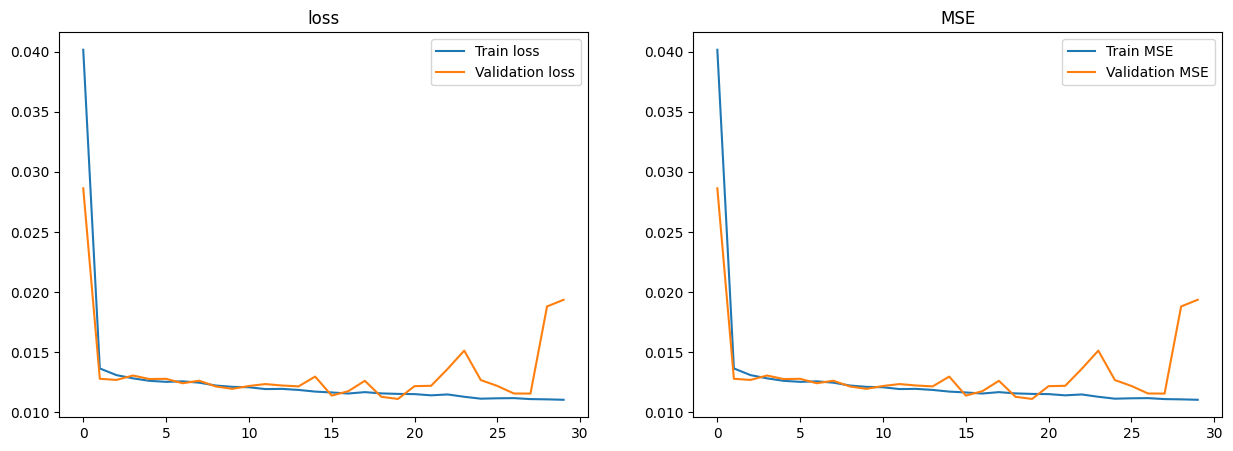

In [46]:
plot_history(history)

### Saving model

In [25]:
joblib.dump(model, "/kaggle/working/unet.joblib")

['/kaggle/working/unet.joblib']

## Testing reconstruction on image from train set

In [47]:
image_color_path = '/kaggle/input/datasets/aayush9753/image-colorization-dataset/data/train_color/image0001.jpg'

In [48]:
img = np.array(Image.open(image_color_path).resize((256,256)))
img.shape
L, ab = rgb_to_lab(np.expand_dims(img, axis=0))

In [49]:
ab_pred = model.predict(L)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


In [50]:
ab_pred.shape

(1, 256, 256, 2)

In [51]:
img_lab_reconstructed = tf.concat([L * 100.0, ab_pred * 128.0], axis=-1)

In [52]:
img_rgb_reconstructed = tfio.experimental.color.lab_to_rgb(img_lab_reconstructed)
img_rgb_reconstructed.shape

TensorShape([1, 256, 256, 3])

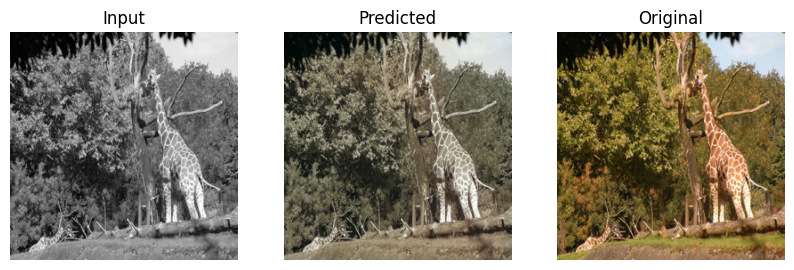

In [53]:
fig, ax = plt.subplots(1, 3, figsize=(10, 10))

ax[0].imshow(np.squeeze(L, axis=0), cmap='grey')
ax[0].axis('off')
ax[0].set_title('Input')

ax[1].imshow(np.squeeze(img_rgb_reconstructed,axis=0))
ax[1].axis('off')
ax[1].set_title('Predicted')

ax[2].imshow(img)
ax[2].axis('off')
ax[2].set_title('Original');